**#IMPORT LIBRARIES**

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix, accuracy_score, f1_score, roc_auc_score)

**#LOAD DATA**

In [42]:
customer_churn = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')

**#DATA INSPECTION**

In [43]:
customer_churn.head()
customer_churn.info()
customer_churn.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


**#CHECK MISSING VALUES**

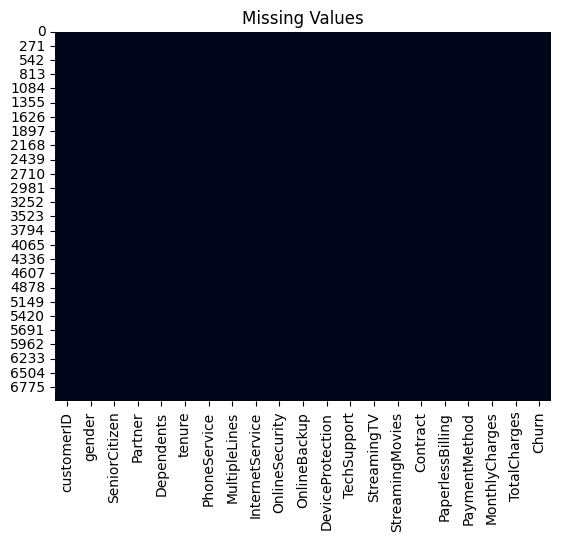

In [16]:
customer_churn.isnull().sum()
sns.heatmap(customer_churn.isnull(), cbar=False)
plt.title('Missing Values')
plt.show()

**#CHECK DUPLICATES**

In [17]:
print('Duplicate Rows:', customer_churn.duplicated().sum())

Duplicate Rows: 0


#**BUSINESS UNDERSTANDING**
#Goal: Predict Customer Churn.
#Questions:
#1.  What is the Churn Rate?
#2.  Does Contract type affect churn?
#3.  Are higher monthly chargers linked to Churn?
#4.  Does tenure  affect churn?
#5.  Which customer groups churn most?







#CHURN RATE

Churn
No     5174
Yes    1869
Name: count, dtype: int64
Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


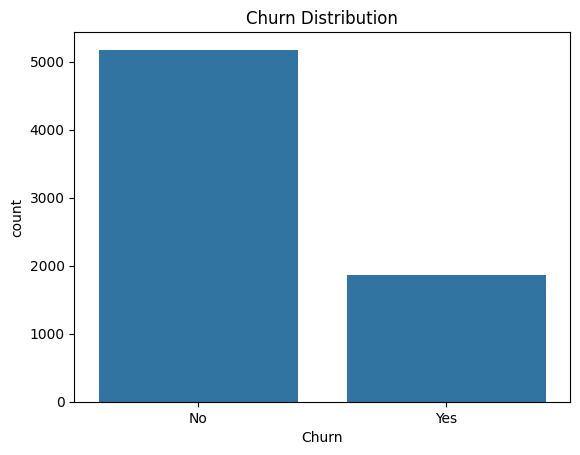

In [19]:
print(customer_churn['Churn'].value_counts())
print(customer_churn['Churn'].value_counts(normalize=True)*100)
sns.countplot(x='Churn', data=customer_churn)
plt.title('Churn Distribution')
plt.show()

#

#CONTRACT TYPE VS CHURN

Churn                 No       Yes
Contract                          
Month-to-month  0.572903  0.427097
One year        0.887305  0.112695
Two year        0.971681  0.028319


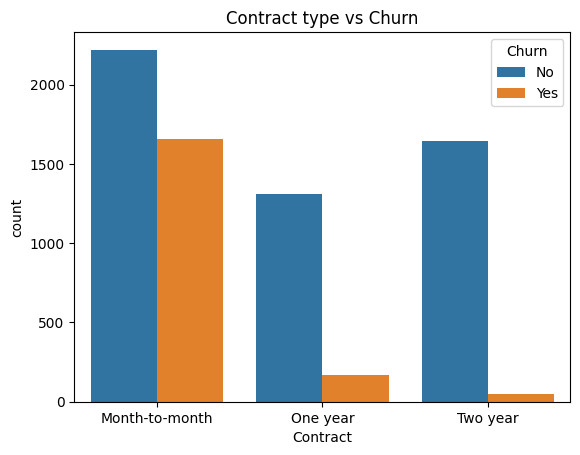

In [21]:
print(pd.crosstab(customer_churn['Contract'], customer_churn['Churn'], normalize = 'index'))
sns.countplot(x='Contract', hue='Churn', data=customer_churn)
plt.title('Contract type vs Churn')
plt.show()

#MONTHLY CHARGES VS CHURN

Churn
No     61.265124
Yes    74.441332
Name: MonthlyCharges, dtype: float64


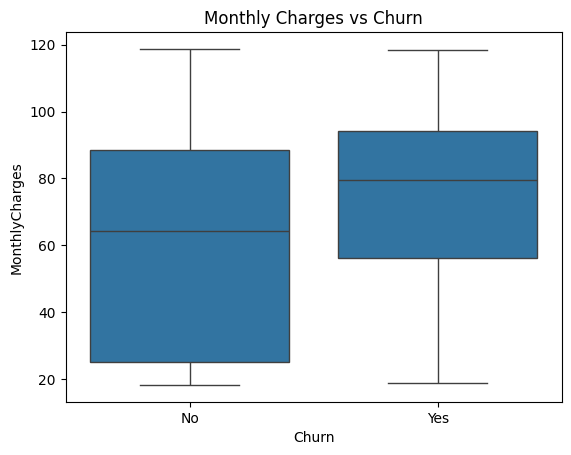

In [22]:
print(customer_churn.groupby('Churn')['MonthlyCharges'].mean())
sns.boxplot(x='Churn', y='MonthlyCharges', data=customer_churn)
plt.title('Monthly Charges vs Churn')
plt.show()

**#TENURE VS CHURN**

Churn
No     37.569965
Yes    17.979133
Name: tenure, dtype: float64


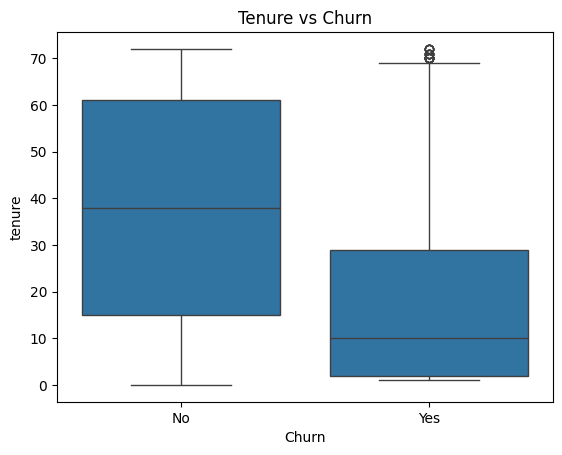

In [44]:
print(customer_churn.groupby('Churn')['tenure'].mean())
sns.boxplot(x='Churn', y='tenure', data=customer_churn)
plt.title('Tenure vs Churn')
plt.show()

**#DEMOGRAPHICS VS CHURN**

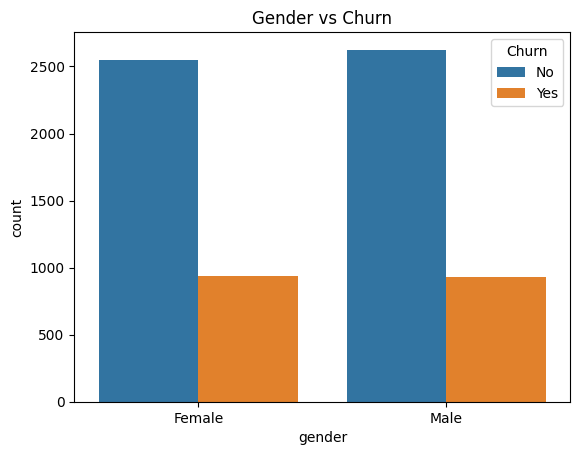

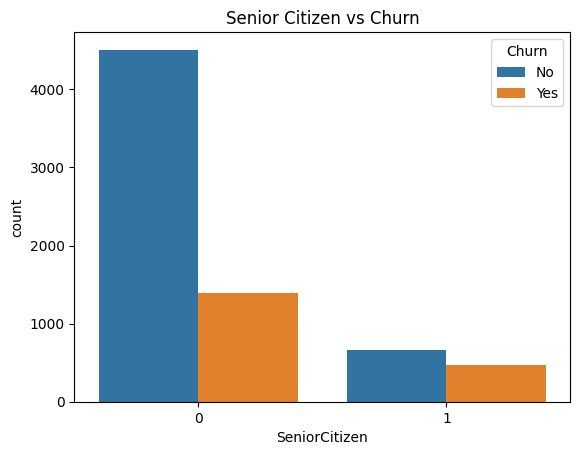

In [45]:
sns.countplot(x='gender', hue='Churn', data=customer_churn)
plt.title('Gender vs Churn')
plt.show()
sns.countplot(x='SeniorCitizen', hue='Churn', data=customer_churn)
plt.title('Senior Citizen vs Churn')
plt.show()

**#NUMERICAL DISTRIBUTION**

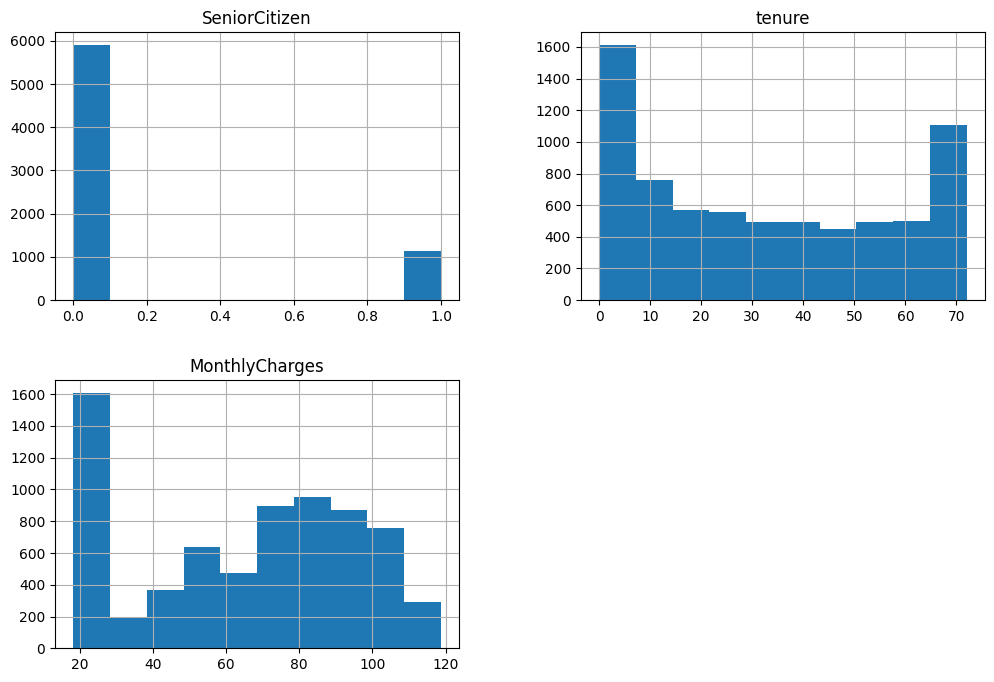

In [26]:
customer_churn.hist(figsize=(12,8))
plt.show()

**#DATA CLEANING**

In [27]:
customer_churn.drop('customerID', axis=1, inplace=True)
customer_churn.dropna(inplace = True)

**#ENCODE CATEGORICAL VARIABLES**

In [28]:
customer_churn = pd.get_dummies(customer_churn, drop_first=True)

**#CORRELATION ANALYSIS**

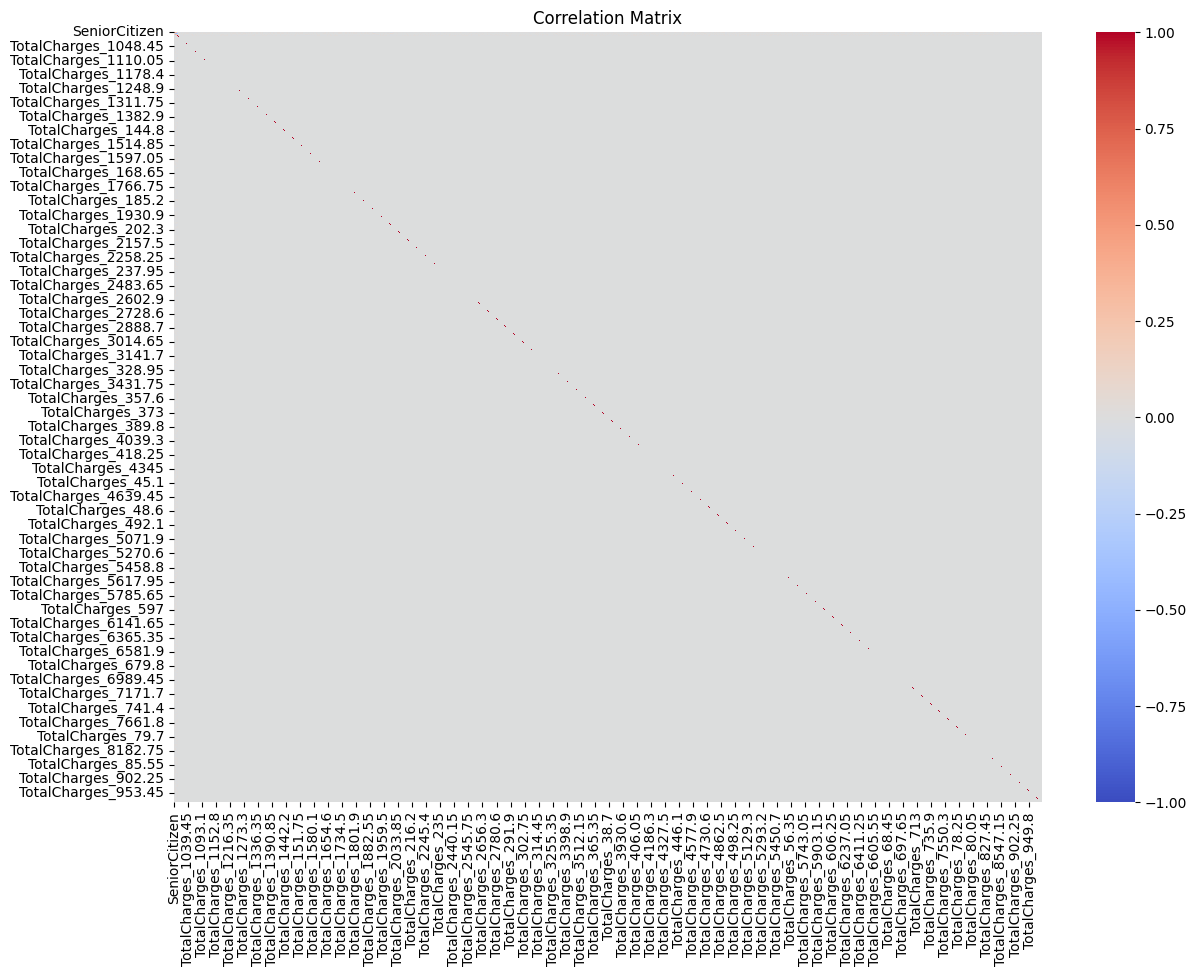

In [29]:
plt.figure(figsize=(14,10))
corr_matrix = customer_churn.corr()
sns.heatmap(corr_matrix, cmap = 'coolwarm')
plt.title('Correlation Matrix')
plt.show()

**#Top Features related to Churn**

In [30]:
if 'Churn_Yes' in customer_churn.columns:
    churn_corr = (customer_churn.corr()['Churn_Yes'].sort_values(ascending=False))
    print(churn_corr.head(15))


Churn_Yes                         1.000000
InternetService_Fiber optic       0.308020
PaymentMethod_Electronic check    0.301919
MonthlyCharges                    0.193356
PaperlessBilling_Yes              0.191825
SeniorCitizen                     0.150889
StreamingTV_Yes                   0.063228
StreamingMovies_Yes               0.061382
MultipleLines_Yes                 0.040102
TotalCharges_69.6                 0.039663
TotalCharges_69.65                0.039663
TotalCharges_75.3                 0.039663
TotalCharges_45.7                 0.034347
TotalCharges_69.1                 0.034347
TotalCharges_74.9                 0.034347
Name: Churn_Yes, dtype: float64


**#FEATURES AND TARGET**

In [37]:
if 'Churn_Yes' in customer_churn.columns:
    X = customer_churn.drop('Churn_Yes', axis=1)
    y = customer_churn['Churn_Yes']
else:
    x = customer_churn.drop('Churn', axis=1)
    y = customer_churn['Churn']

**#TRAIN TEST SPLIT**

In [32]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.20, random_state = 42, stratify=y)
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(5634, 6559) (1409, 6559) (5634,) (1409,)


**#FEATURE SCALING**
#(FOR LOGISTIC REGRESSION)

In [33]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

**#LOGISTIC REGRESSION**

In [34]:
logreg = LogisticRegression()
logreg.fit(X_train, y_train)
y_pred = logreg.predict(X_test)
y_pred_proba = logreg.predict_proba(X_test)[:,1]
print('LOGISTIC REGRESSION RESULTS')
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print('Accuracy:', accuracy_score(y_test, y_pred))
print('F1 Score:', f1_score(y_test, y_pred))
print('ROC AUC:', roc_auc_score(y_test, y_pred_proba))

LOGISTIC REGRESSION RESULTS
              precision    recall  f1-score   support

       False       0.83      0.88      0.85      1035
        True       0.59      0.50      0.54       374

    accuracy                           0.78      1409
   macro avg       0.71      0.69      0.70      1409
weighted avg       0.77      0.78      0.77      1409

[[906 129]
 [186 188]]
Accuracy: 0.7764371894960965
F1 Score: 0.5441389290882779
ROC AUC: 0.8025988788137126


**#RANDOM FOREST**

In [35]:
rf = RandomForestClassifier(random_state = 42, n_estimators = 200)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
y_proba_rf = rf.predict_proba(X_test)[:,1]
print('RANDOM FOREST RESULTS')
print(classification_report(y_test, y_pred_rf))
print(confusion_matrix(y_test, y_pred_rf))
print('Accuracy:', accuracy_score(y_test, y_pred_rf))
print('F1 Score:', f1_score(y_test, y_pred_rf))
print('ROC AUC:', roc_auc_score(y_test, y_pred_proba))


RANDOM FOREST RESULTS
              precision    recall  f1-score   support

       False       0.83      0.91      0.87      1035
        True       0.66      0.47      0.55       374

    accuracy                           0.79      1409
   macro avg       0.74      0.69      0.71      1409
weighted avg       0.78      0.79      0.78      1409

[[946  89]
 [200 174]]
Accuracy: 0.794889992902768
F1 Score: 0.5463108320251178
ROC AUC: 0.8025988788137126


**#FEATURE IMPORTANCE**

                           Feature  importance
1                           tenure    0.120098
2                   MonthlyCharges    0.093543
27  PaymentMethod_Electronic check    0.028786
24               Contract_Two year    0.027891
9      InternetService_Fiber optic    0.024729
12              OnlineSecurity_Yes    0.022743
18                 TechSupport_Yes    0.021118
25            PaperlessBilling_Yes    0.020680
23               Contract_One year    0.019556
3                      gender_Male    0.018799
14                OnlineBackup_Yes    0.017065
4                      Partner_Yes    0.016783
0                    SeniorCitizen    0.014551
16            DeviceProtection_Yes    0.014542
5                   Dependents_Yes    0.014198


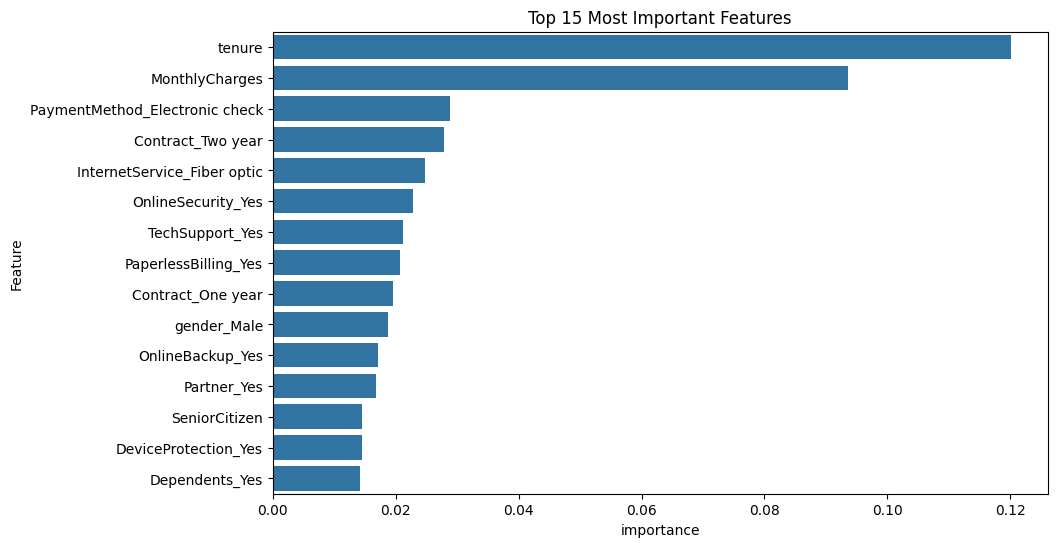

In [38]:
feature_importance = pd.DataFrame({'Feature': X.columns, 'importance': rf.feature_importances_})
feature_importance = (feature_importance.sort_values(by='importance', ascending=False))
print(feature_importance.head(15))
plt.figure(figsize=(10,6))
sns.barplot(x='importance', y='Feature', data = feature_importance.head(15))
plt.title('Top 15 Most Important Features')
plt.show()